In [2]:
import pandas as pd

In [3]:
#loading the file in again
file_path = "/Users/vaishnavinibhanupudi/Downloads/loan_prediction/data/raw/Loan_Default 3.csv"
df = pd.read_csv(file_path)

In [4]:
#stripping empty white space, normalizing to lowercase, and normalizing " " (space) between words to underscore
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [5]:
df.columns

Index(['id', 'year', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'credit_worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'interest_rate_spread', 'upfront_charges', 'term', 'neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'income', 'credit_type', 'credit_score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'ltv', 'region', 'security_type',
       'status', 'dtir1'],
      dtype='object')

In [6]:
#from EDA, we know that ID and year columns can be dropped. 
#ID is a unique identifier and year is uniform for all values (2019). Therefore, these don't contribute meaningfully
df = df.drop(columns=["id", "year"])

In [7]:
df.columns

Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type',
       'credit_score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'ltv', 'region', 'security_type', 'status',
       'dtir1'],
      dtype='object')

In [8]:
df.head(5)

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  object 
 1   gender                     148670 non-null  object 
 2   approv_in_adv              147762 non-null  object 
 3   loan_type                  148670 non-null  object 
 4   loan_purpose               148536 non-null  object 
 5   credit_worthiness          148670 non-null  object 
 6   open_credit                148670 non-null  object 
 7   business_or_commercial     148670 non-null  object 
 8   loan_amount                148670 non-null  int64  
 9   rate_of_interest           112231 non-null  float64
 10  interest_rate_spread       112031 non-null  float64
 11  upfront_charges            109028 non-null  float64
 12  term                       148629 non-null  float64
 13  neg_ammortization          14

**Verifying data types**: The dataset seems to contain appropriate data types for each feature, so no data type conversions are needed as part of preprocessing

**Missing value analysis**

In [10]:
df.isnull().sum()

loan_limit                    3344
gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
credit_worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
interest_rate_spread         36639
upfront_charges              39642
term                            41
neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
secured_by                       0
total_units                      0
income                        9150
credit_type                      0
credit_score                     0
co-applicant_credit_type         0
age                            200
submission_of_application      200
ltv                          15098
region              

To determine how to handle rows with missing values, we want to analyze why the data is missing, how much of the data is missing, what type of variable it is, and how the model will handle missing values. 

First, we will calculate the percentages of missing values:

In [11]:
#isnull assigns true (is null) or false to each entry in each column --> true = 1 and false = 0, so using mean() we are calculating the proportion of true rows or in other words, the proportion of null rows, in each column
df.isnull().mean().sort_values(ascending = False) * 100

upfront_charges              26.664425
interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
ltv                          10.155378
property_value               10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
neg_ammortization             0.081388
term                          0.027578
status                        0.000000
security_type                 0.000000
region                        0.000000
co-applicant_credit_type      0.000000
credit_score                  0.000000
credit_type                   0.000000
open_credit                   0.000000
total_units                   0.000000
business_or_commercial        0.000000
occupancy_type                0.000000
construction_type             0.000000
gender                   

Note, the target variable status has no missing values

In our initial analysis, we found that about 25% of the dataset consists of defaults and about 75% of the dataset consists of non-defaults.

First, I will analyze the proportion of null rows in the upfront_charges column amongst each status group (non-default vs default). This allows us to analyze how missingness behaves across a particular class. 

In [12]:
df.groupby("status")["upfront_charges"].apply(lambda x : x.isnull().mean())

status
0    0.028171
1    0.995824
Name: upfront_charges, dtype: float64

The above findings show that 99.5% of rows in the default status group contain missing values in the upfront_charges column. In other words, most default rows tend to have missing values in this specific column, suggesting a systematic pattern of missingness that may potentially be predictive. 

I want to examine how the proportion of the status variable differs amongst the null rows for the upfront_charges feature. 

Why? What does this answer?: It allows us to see, among all the rows which have a missing value for a particular column, how does the target feature (status) differ? 

In [13]:
df[df["upfront_charges"].isnull()]["status"].value_counts(normalize = True)

status
1    0.920387
0    0.079613
Name: proportion, dtype: float64

Looking at all the rows with missing values for the upfront_charges column, we can see that 92% of these rows are defaults and about 7.96% are non-defaults. This tells us that most of the null rows for the upfront_charges variable are defaults, reinforcing our previous findings that there may be an underlying reason for missing values in the upfront_charges column. 

Investigating the missing values in the interest_rate_spread column:

In [14]:
df.groupby("status")["interest_rate_spread"].apply(lambda x : x.isnull().mean())

status
0    0.0
1    1.0
Name: interest_rate_spread, dtype: float64

In [15]:
df[df["interest_rate_spread"].isnull()]["status"].value_counts(normalize=True)

status
1    1.0
Name: proportion, dtype: float64

The above analysis shows a strong relationship between missing values in the interest_rate_spread and the default status group. By conditioning on status, to analyze the number of missing values in the interest_rate_spread column within each status group, we found that the non-default class (status = 0), contains no rows with missing values in the column. On the other hand, 100% of the rows in the defaulted status group (status = 1), contain missing values in the interest_rate_spread column. This again suggests that interest_rate_spread is predictive of status and reinforces our earlier exploration in the initial exploratory analysis. Conditioning on the rows with missing values in the interest_rate_spread column, we can see that all of the missing rows in the interest_rate_spread column belong to the default status group, reinforcing the first conditional analysis.

In [16]:
df.groupby("status")["rate_of_interest"].apply(lambda x : x.isnull().mean())

status
0    0.000000
1    0.994541
Name: rate_of_interest, dtype: float64

In [17]:
df[df["rate_of_interest"].isnull()]["status"].value_counts(normalize=True)

status
1    1.0
Name: proportion, dtype: float64

The above analysis shows similar findings for rate_of_interest. There seems to be a strong relationship between missing values in this column and the defaulted status group. By conditioning on status and examining those rows in the rate_of_interest column that are null, we can see that approximately 99.5% of defaults have a missing value in the rate_of_interest column. This suggests that this missingness is potentially predictive by indicating that defaulted loans (status = 1), tend to not have a rate_of_interest recorded. 

By conditioning on the null values in the rate_of_interest column and examining the value of status, we can see that all null values in the rate_of_interest column belong to the defaulted status class. 

These findings indicate that this missingness is systemic and meaningful. 

This is also interesting because previously our boxplots found that status had a larger median rate of interest and smaller spread of data. Considering that about 99.5% of defaulted rows have a null value for the rate_of_interest and we have 148670 rows, that means the boxplot is only representing the median calculated off of 743 rows. This is a much smaller subset of the total data and suggests that the distribution observed by the boxplot may not be representative of the overall dataset. 

Another interesting finding is that, in our initial analysis, we found that the dataset is composed of about 24.6445% defaulted loans. Our above analysis indicates that for the upfront_charges, interest_rate_spread, and rate_of_interest variables, which contain between 24.51% and 26.67% of missing values, close to 100% of defaulted loans in the dataset have missing values in these columns. In fact, the proportion of missing values for the interest_rate_spread is 24.6445%, which is exactly the proportion of defaulted loans in the total dataset. 

We therefore must consider whether missingness in these columns, particularly the interest_rate_spread column, is a source of data leakage for the target variable. The proportion of missingness in these columns carries information about the proportion of defaulted loans overall, so we should evaluate how we use these variables during model development. 

While the variables appear to be general loan characteristics, without documentation on when these features were captured during the loan tracking lifestyle, we cannot rule out that the missingness for these columns is a result of the target outcome. 

Given our above analyses, while imputing these values, as mentioned previously, we should be careful to preserve a signal of their missingness. However, because this divisive missingness is unlikely to generalize to all future and real-world datasets, the final model should not rely exclusively on these missingness patterns. Instead, it should also learn predictive relationships from underlying financial characteristics.

Continuing to investigate missing values across debt-to-income ratio (dtir1), loan-to-value (ltv), property value, and income, which contain smaller proportions of missing values:

In [18]:
df.groupby("status")["dtir1"].apply(lambda x : x.isnull().mean())

status
0    0.069722
1    0.445154
Name: dtir1, dtype: float64

In [19]:
df[df["dtir1"].isnull()]["status"].value_counts(normalize = True)

status
1    0.676174
0    0.323826
Name: proportion, dtype: float64

We found that 44.51% of defaulted loans have missing values for the dtir1 column, while only 6.97% of non-defaulted loans have a missing value in the dtir1 column. This suggests that the missingness of this value is meaningful, though it is less divisive and strongly predictive than some of the previous columns we analyzed.

Looking at the conditional proportions of status given missing values in the dtir1 column, we see that of the rows that have missing values in this column, 67.6% of these belong to the defaulted group, and 32.4% of these belong to the non-default group. These findings also suggest that the missingness may be meaningful as the defaulted group accounts for more missing values in the dtir1 column.

Analyzing ltv:

In [20]:
df.groupby("status")["ltv"].apply(lambda x : x.isnull().mean())

status
0    0.000018
1    0.412020
Name: ltv, dtype: float64

In [21]:
df[df["ltv"].isnull()]["status"].value_counts(normalize=True)

status
1    0.999868
0    0.000132
Name: proportion, dtype: float64

The above findings show that approximately 41% of defaulted loans contain missing values in the ltv column, compared to a very small percentage of non-defaulted loans. The second conditional analysis shows that of the null values in the ltv column, more than 99% of these null rows correspond to defaulted loans. 

These findings indicate a strong association between missing values in the loan-to-value column and default status. 

Analyzing property value

In [22]:
df.groupby("status")["property_value"].apply(lambda x : x.isnull().mean())

status
0    0.000018
1    0.412020
Name: property_value, dtype: float64

In [23]:
df[df["property_value"].isnull()]["status"].value_counts(normalize=True)

status
1    0.999868
0    0.000132
Name: proportion, dtype: float64

These findings demonstrate that 41% of defaulted loans have missing values in the property_value column and that of the total null values in the property_value column, more than 99% of these belong to the defaulted loans class. I also notice that the proportions of missing values for the property_value column are the exact same as those for the loan-to-value column. This is likely because the loan-to-value ratio is computed as Loan Amount/Property Value, and therefore, a missing value in the property column corresponds with a missing value in the LTV column. 

However, unlike interest_rate_spread and rate_of_interest, where nearly all defaulted loans have missing values, only about 41% of defaulted loans have missing property_value and ltv. Therefore, while the association remains strong, the missingness is not as deterministic.

Analyzing income:

In [24]:
df.groupby("status")["income"].apply(lambda x : x.isnull().mean())

status
0    0.070614
1    0.033816
Name: income, dtype: float64

In [25]:
df[df["income"].isnull()]["status"].value_counts(normalize=True)

status
0    0.86459
1    0.13541
Name: proportion, dtype: float64

Analyzing missing values in the income column, I observe that around 7% of non-defaults have missing values in the income column, compared to around 3% of defaults. I also observe that of the missing values in the income column, approximatelt 86.5% of the values are non-defaulted loans, while 13.54% are defaulted loans. 

Unlike some of the other variables previously analyzed, the difference in missingness across the default and non-default groups (3% vs 7%) is relatively small. This suggests that for the income variable missing values are less meaningful for loan status. While about 86.5% of missing values in the column belong to the non-default class, this can likely be explained by the fact that the dataset overall has more non-defaulted loans. 

Examining loan_limit, approv_in_adv, submission_of_application, age, loan_purpose, neg_ammortization, term

In [26]:
categorical_null_cols = ["loan_limit", "approv_in_adv", "submission_of_application", "age", "loan_purpose", "neg_ammortization", "term"]
for col in categorical_null_cols:
    print(col)
    print(df.groupby("status")[col].apply(lambda x : x.isnull().mean()))
    print(df[df[col].isnull()]["status"].value_counts(normalize=True))
    print("\n")


loan_limit
status
0    0.021985
1    0.024045
Name: loan_limit, dtype: float64
status
0    0.736543
1    0.263457
Name: proportion, dtype: float64


approv_in_adv
status
0    0.005954
1    0.006578
Name: approv_in_adv, dtype: float64
status
0    0.734581
1    0.265419
Name: proportion, dtype: float64


submission_of_application
status
0    0.000000
1    0.005459
Name: submission_of_application, dtype: float64
status
1    1.0
Name: proportion, dtype: float64


age
status
0    0.000000
1    0.005459
Name: age, dtype: float64
status
1    1.0
Name: proportion, dtype: float64


loan_purpose
status
0    0.000884
1    0.000955
Name: loan_purpose, dtype: float64
status
0    0.738806
1    0.261194
Name: proportion, dtype: float64


neg_ammortization
status
0    0.000794
1    0.000873
Name: neg_ammortization, dtype: float64
status
0    0.735537
1    0.264463
Name: proportion, dtype: float64


term
status
0    0.000232
1    0.000409
Name: term, dtype: float64
status
0    0.634146
1    0.365854
Na

Overall, across the categorical variables with missing values, missingness appears to be much less systematic than for the numerical variables. For most variables, the proportion of missing values within the default and non-default groups is very similar. Additionally, the conditional distribution of loan status among observations with missing values is generally close to the overall dataset distribution (approximately 74% non-default and 26% default), suggesting that missingness is not strongly associated with the target variable.

Two exceptions are submission_of_application and age, where all observations with missing values belong to the default class. While this may indicate a potential association between missingness and loan default, the overall proportion of missing values in these variables is extremely small (approximately 0.55% of defaulted loans). Therefore, this pattern should be interpreted cautiously, as it may reflect only a handful of observations rather than a widespread systematic missingness.

**Handling Missing Values**

Our previous analysis found that missing values in the rate_of_interest, interest_rate_spread, and upfront_charges were very strongly associated with the defaulted loan group. While we can consider maintaining flags to denote missing value rows for these columns, because this strong association may be unlikely to be observed in real-world loan data, including these flag columns in the training dataset may cause the model to learn these strong associations and miss other, more generalizable financial patterns. 

We will use median imputation to handle missing values in numerical columns, as many features in the dataset contain skewed distributions. For example, upfront_charges is heavily right-skewed. Median imputation is robust against outliers and extreme observations, providing a more balanced method of imputation (compared to mean imputation for skewed data). To handle missing values in categorical columns, we will use the mode of the column.

Although several variables exhibited informative missingness, I have decided not to include missing-value indicator features because the missingness appeared to be strongly associated with the target variable and could reflect characteristics of the data collection process rather than information available at prediction time. This imputation method ensures a more generalizable model. 

Before imputing, I will split the data into training and testing data. This will ensure that the imputation values (for example, median and mode) are not affected by the test set. I will use an 80:20 train-test split and stratify on the target variable (status), to ensure that the proportion of defaults vs non-defaults in the train and test sets are the same as the overall dataset.

I will define the feature dataframe X, and the target series y. 

In [29]:
X = df.drop(columns="status")
y = df["status"] #y is the target variable

numerical_cols = X.select_dtypes(include="number").columns #selecting the numerical columns in the feature dataframe X (does not include status)
categorical_cols = X.select_dtypes(include="object").columns


In [30]:
#we only want to impute the missing values in the train and test splits using the median (numerical) and mode (categorical) from the train split. 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.impute import SimpleImputer

#now we use simple imputer to impute using the median for numerical columns of the training data
imputer = SimpleImputer(strategy="median")
X_train[numerical_cols] = imputer.fit_transform(X_train[numerical_cols]) #note we used fit_transform because we are calculating the median of the training set and then applying that to the training set
X_test[numerical_cols] = imputer.transform(X_test[numerical_cols])

#using simple imputer to impute using the mode for categorical columns of the training data
imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = imputer.transform(X_test[categorical_cols])


In [31]:
#after imputing numerical cols missing vals with median and categorical cols missing values with mode, checking to see if there are still null values in the feature dataframe
X_train.isnull().sum().sort_values(ascending=False)

loan_limit                   0
property_value               0
security_type                0
region                       0
ltv                          0
submission_of_application    0
age                          0
co-applicant_credit_type     0
credit_score                 0
credit_type                  0
income                       0
total_units                  0
secured_by                   0
occupancy_type               0
construction_type            0
lump_sum_payment             0
gender                       0
interest_only                0
neg_ammortization            0
term                         0
upfront_charges              0
interest_rate_spread         0
rate_of_interest             0
loan_amount                  0
business_or_commercial       0
open_credit                  0
credit_worthiness            0
loan_purpose                 0
loan_type                    0
approv_in_adv                0
dtir1                        0
dtype: int64

In [34]:
X_test.isnull().sum().sort_values(ascending = False)

loan_limit                   0
property_value               0
security_type                0
region                       0
ltv                          0
submission_of_application    0
age                          0
co-applicant_credit_type     0
credit_score                 0
credit_type                  0
income                       0
total_units                  0
secured_by                   0
occupancy_type               0
construction_type            0
lump_sum_payment             0
gender                       0
interest_only                0
neg_ammortization            0
term                         0
upfront_charges              0
interest_rate_spread         0
rate_of_interest             0
loan_amount                  0
business_or_commercial       0
open_credit                  0
credit_worthiness            0
loan_purpose                 0
loan_type                    0
approv_in_adv                0
dtir1                        0
dtype: int64

After imputing missing values in numerical columns with the median of each column and those in categorical columns with the mode of each column, I confirmed that there are no longer anymore missing values. After this, we can move to the feature selection step.

**Feature Encoding and Data Preparation**

Previously, we already dropped year and ID from the dataset, as year is constant throughout the data and ID just represents the unique identifier for each loan. 

In our initial analysis, we observed pairwise correlations, identifying potential signs of multicollinearity as well as how features varied based on the target variable's value. While this correlation analysis gave us an initial understanding of potential feature interaction, it is not enough to completely assess multicollinearity and feature relationships/patterns.

While tree-based models like Random Forest and XGBoost are less dependent on feature selection, feature selection is important for our logistic regression model to ensure we are not including irrelevant or redundant features and that our model will generalize well to unseen data. 

To analyze multicollinearity more thoroughly, we will compute the VIF (Variance Inflation Factor). High VIF values indicate that a variable is strongly correlated with other features.

In [32]:
#Variance Inflation Factor takes one feature and regresses it against all other features, computing the VIF. It does this for each numerical feature

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

#VIF is only calculated for numerical columns
#X represents the feature variables, X_train contains the rows in the training set (after train-test split)
X_vif = X_train.select_dtypes(include="number")

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i) #X.values converts the dataframe into a numpy array for variance_inflation_factor
    for i in range(X_vif.shape[1]) #X.shape gives number of rows and columns in the dataframe, we want the number of columns because we are looping through the numerical columns
]

#sorting so that the top VIF columns are at the top
vif.sort_values(by="VIF", ascending=False)


,Feature,VIF
1,rate_of_interest,75.091267
4,term,40.436036
7,credit_score,29.173433
9,dtir1,16.576069
0,loan_amount,9.879702
5,property_value,6.596273
8,ltv,4.581597
2,interest_rate_spread,3.462972
6,income,2.947869
3,upfront_charges,2.184450


Overall, some variables seem to have high VIF values. In other words, variables like rate_of_interest, term, credit_score, and dtir1 seem to be strongly correlated with other values, so these are strong sources of multicollinearity. 

While the VIF values are high, they are not necessarily odd or unexpected, given that several financial metrics are determined given other metrics. For example, a loan's interest rate takes into account several other characteristics of the applicant and loan, such as credit score, term, debt-to-income ratio, the amount of the loan, the type of loan, and more. 

Additionally, variables like loan-to-value ratio (ltv) and interest_rate_spread are computed directly using other variables. Loan-to-value ratio is computed by dividing the loan_amount by the property_value and interest_rate_spread is computed by comparing the rate_of_interest to a benchmark interest rate. 

These findings build upon our initial pairwise correlation analysis where we found that features like loan_amount and property_value, rate_of_interest and interest_rate_spread, and income and property_value had strong correlations. The VIF analysis allows us to explore how features can be formed using linear combinations of other predictor features. 

Looking at the VIF values, we understand that there is multicollinearity amongst our features. Therefore, to ensure a generalizable model that is not overfitting, for our baseline logistic regression model, we will apply Ridge Regularization. 

**Baseline Model Development: L2 (Ridge) Regularized Logistic Regression**

Before applying the ridge regularized logistic regression model, I will encode categorical features using OneHot Encoding. I want to encode only the categorical features that are part of the training data to avoid data leakage into the test set.

Prior to imputation, I split the predictor data into training and testing data. 

In [89]:
print(X_train.shape[0])
print(X_test.shape[0])

118936
29734


In [106]:
print(y_train.shape[0])
print(y_test.shape[0])

118936
29734


In [91]:
#Verifying stratification
print(y_train.value_counts(normalize=True))

status
0    0.753557
1    0.246443
Name: proportion, dtype: float64


In [92]:
print(y_test.value_counts(normalize=True))

status
0    0.753548
1    0.246452
Name: proportion, dtype: float64


In [135]:
print(y_train.value_counts())

status
0    89625
1    29311
Name: count, dtype: int64


In [136]:
print(y_test.value_counts())

status
0    22406
1     7328
Name: count, dtype: int64


In [37]:
from sklearn.preprocessing import OneHotEncoder

#first we need to select the categorical columns we want to apply OneHotEncoder to
categorical_cols = X_train.select_dtypes(include=["object"]).columns
categorical_cols

Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'region', 'security_type'],
      dtype='object')

In [38]:
#creating the encoder
encoder = OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False) #drop='first' to prevent dummy multicollinearity by having the same values but flipped
#no scipy sparse matrix, just numpy array so sparse_output = false


We will use fit_transform to learn the categories from the training dataset and then numerically encode these

In [39]:
#Encoding the categorical columns in the training data
X_train_encoded = encoder.fit_transform(X_train[categorical_cols]) #fit_transform applies to the training data only
#fit_transform: fit is collecting the categories that exist. in general fit is making calculations from the dataset. transform is then applying the findings

Now we apply these encodings to the test set

In [40]:
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [41]:
print(encoder.categories_)

[array(['cf', 'ncf'], dtype=object), array(['Female', 'Joint', 'Male', 'Sex Not Available'], dtype=object), array(['nopre', 'pre'], dtype=object), array(['type1', 'type2', 'type3'], dtype=object), array(['p1', 'p2', 'p3', 'p4'], dtype=object), array(['l1', 'l2'], dtype=object), array(['nopc', 'opc'], dtype=object), array(['b/c', 'nob/c'], dtype=object), array(['neg_amm', 'not_neg'], dtype=object), array(['int_only', 'not_int'], dtype=object), array(['lpsm', 'not_lpsm'], dtype=object), array(['mh', 'sb'], dtype=object), array(['ir', 'pr', 'sr'], dtype=object), array(['home', 'land'], dtype=object), array(['1U', '2U', '3U', '4U'], dtype=object), array(['CIB', 'CRIF', 'EQUI', 'EXP'], dtype=object), array(['CIB', 'EXP'], dtype=object), array(['25-34', '35-44', '45-54', '55-64', '65-74', '<25', '>74'],
      dtype=object), array(['not_inst', 'to_inst'], dtype=object), array(['North', 'North-East', 'central', 'south'], dtype=object), array(['Indriect', 'direct'], dtype=object)]


In [42]:
#now the columns are numpy arrays, we want to map them back into dataframes and assign them meaningful column names
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
print(encoded_feature_names)

['loan_limit_ncf' 'gender_Joint' 'gender_Male' 'gender_Sex Not Available'
 'approv_in_adv_pre' 'loan_type_type2' 'loan_type_type3' 'loan_purpose_p2'
 'loan_purpose_p3' 'loan_purpose_p4' 'credit_worthiness_l2'
 'open_credit_opc' 'business_or_commercial_nob/c'
 'neg_ammortization_not_neg' 'interest_only_not_int'
 'lump_sum_payment_not_lpsm' 'construction_type_sb' 'occupancy_type_pr'
 'occupancy_type_sr' 'secured_by_land' 'total_units_2U' 'total_units_3U'
 'total_units_4U' 'credit_type_CRIF' 'credit_type_EQUI' 'credit_type_EXP'
 'co-applicant_credit_type_EXP' 'age_35-44' 'age_45-54' 'age_55-64'
 'age_65-74' 'age_<25' 'age_>74' 'submission_of_application_to_inst'
 'region_North-East' 'region_central' 'region_south'
 'security_type_direct']


In [43]:
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index = X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index = X_test.index)

In [44]:
#now putting the encoded categorical columns along with the rest of the dataframe
X_train_numeric = X_train.drop(columns=categorical_cols)
X_test_numeric = X_test.drop(columns=categorical_cols)

X_train = pd.concat([X_train_numeric, X_train_encoded], axis=1) #axis = 1 because we are concatenating horizontally (columns with each other)
X_test = pd.concat([X_test_numeric, X_test_encoded], axis=1) 

In [45]:
print(X_train.columns)

Index(['loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'property_value', 'income', 'credit_score',
       'ltv', 'dtir1', 'loan_limit_ncf', 'gender_Joint', 'gender_Male',
       'gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2',
       'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3',
       'loan_purpose_p4', 'credit_worthiness_l2', 'open_credit_opc',
       'business_or_commercial_nob/c', 'neg_ammortization_not_neg',
       'interest_only_not_int', 'lump_sum_payment_not_lpsm',
       'construction_type_sb', 'occupancy_type_pr', 'occupancy_type_sr',
       'secured_by_land', 'total_units_2U', 'total_units_3U', 'total_units_4U',
       'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP',
       'co-applicant_credit_type_EXP', 'age_35-44', 'age_45-54', 'age_55-64',
       'age_65-74', 'age_<25', 'age_>74', 'submission_of_application_to_inst',
       'region_North-East', 'region_central', 'region_south',
       's

In [46]:
print(X_test.columns)

Index(['loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'property_value', 'income', 'credit_score',
       'ltv', 'dtir1', 'loan_limit_ncf', 'gender_Joint', 'gender_Male',
       'gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2',
       'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3',
       'loan_purpose_p4', 'credit_worthiness_l2', 'open_credit_opc',
       'business_or_commercial_nob/c', 'neg_ammortization_not_neg',
       'interest_only_not_int', 'lump_sum_payment_not_lpsm',
       'construction_type_sb', 'occupancy_type_pr', 'occupancy_type_sr',
       'secured_by_land', 'total_units_2U', 'total_units_3U', 'total_units_4U',
       'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP',
       'co-applicant_credit_type_EXP', 'age_35-44', 'age_45-54', 'age_55-64',
       'age_65-74', 'age_<25', 'age_>74', 'submission_of_application_to_inst',
       'region_North-East', 'region_central', 'region_south',
       's

In [47]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 118936 entries, 141039 to 118320
Data columns (total 48 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   loan_amount                        118936 non-null  float64
 1   rate_of_interest                   118936 non-null  float64
 2   interest_rate_spread               118936 non-null  float64
 3   upfront_charges                    118936 non-null  float64
 4   term                               118936 non-null  float64
 5   property_value                     118936 non-null  float64
 6   income                             118936 non-null  float64
 7   credit_score                       118936 non-null  float64
 8   ltv                                118936 non-null  float64
 9   dtir1                              118936 non-null  float64
 10  loan_limit_ncf                     118936 non-null  float64
 11  gender_Joint                       1189

In [48]:
print(X_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29734 entries, 59366 to 134992
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   loan_amount                        29734 non-null  float64
 1   rate_of_interest                   29734 non-null  float64
 2   interest_rate_spread               29734 non-null  float64
 3   upfront_charges                    29734 non-null  float64
 4   term                               29734 non-null  float64
 5   property_value                     29734 non-null  float64
 6   income                             29734 non-null  float64
 7   credit_score                       29734 non-null  float64
 8   ltv                                29734 non-null  float64
 9   dtir1                              29734 non-null  float64
 10  loan_limit_ncf                     29734 non-null  float64
 11  gender_Joint                       29734 non-null  flo

After One-Hot Encoding, all the columns are of numerical data types. Looking at the column names, we can also see that the categorical columns have been reshaped to be the column name_value. Each such column has a 1 to denote that value being present and 0 to denote that value being absent (for the original rows in the dataset).

The next step to preprocess data before training the logistic regression baseline model is to standardize the data. This is important because the dataset consists of values with differing ranges and scales. For a regression model, each coefficient captures how the prediction changes for every 1 unit increase in the feature. However, because the scales are vastly different, a one unit increase for one variable may not represent the same amount of increase for another variable. In other words, by scaling, we are quantifying the one unit increase in terms of a unit increase in the standard deviation of the variable, where we normalize each variable such that the mean is 0 and the standard deviation is 1. This makes the coefficients apply on the same scale for each feature and makes our understanding of how the target is affected by a 1 unit increase more comparable. 

In [49]:
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

#Maintaining a copy of the train and test dataframes before applying scaling (the unscaled versions will be used for tree models)

In [50]:
#Applying Standard Scaler
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
scaler.fit(X_train_numeric) #learns the mean and variance of each feature
X_train_numeric_scaled = scaler.transform(X_train_numeric) #storing X_train_scaled, which will be used for logistic regression
#we will use X_train (not scaled) for the tree-based models
X_test_numeric_scaled = scaler.transform(X_test_numeric) #we dont reapply fit to the test set!


In [51]:
#convert the numpy arrays to dataframes
X_train_numeric_scaled = pd.DataFrame(
    X_train_numeric_scaled,
    columns=X_train_numeric.columns,
    index=X_train_numeric.index
)

X_test_numeric_scaled = pd.DataFrame(
    X_test_numeric_scaled, 
    columns=X_test_numeric.columns,
    index=X_test_numeric.index
)

In [52]:
X_train_scaled = pd.concat([X_train_numeric_scaled, X_train_encoded], axis=1)
X_test_scaled = pd.concat([X_test_numeric_scaled, X_test_encoded], axis=1)
#Defining the scaled train and test dataframes by concatenating the scaled numeric values to the one-hot encoded categorical columns

In [53]:
print(X_train_scaled.columns)

Index(['loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'property_value', 'income', 'credit_score',
       'ltv', 'dtir1', 'loan_limit_ncf', 'gender_Joint', 'gender_Male',
       'gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2',
       'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3',
       'loan_purpose_p4', 'credit_worthiness_l2', 'open_credit_opc',
       'business_or_commercial_nob/c', 'neg_ammortization_not_neg',
       'interest_only_not_int', 'lump_sum_payment_not_lpsm',
       'construction_type_sb', 'occupancy_type_pr', 'occupancy_type_sr',
       'secured_by_land', 'total_units_2U', 'total_units_3U', 'total_units_4U',
       'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP',
       'co-applicant_credit_type_EXP', 'age_35-44', 'age_45-54', 'age_55-64',
       'age_65-74', 'age_<25', 'age_>74', 'submission_of_application_to_inst',
       'region_North-East', 'region_central', 'region_south',
       's

In [54]:
X_train_scaled.head(10)

,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,dtir1,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,region_North-East,region_central,region_south,security_type_direct
141039,-0.679659,-2.364451,-1.954329,-0.810422,0.426117,0.786317,-0.082225,-0.205652,-1.119213,-2.890982,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
121276,0.739828,0.446816,-0.534155,-1.016232,0.426117,0.522407,-0.278868,-0.214287,-0.077265,1.143579,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11214,-0.024511,-0.084769,-0.085985,-0.162874,0.426117,0.639701,-0.644062,-0.922388,-0.657518,1.764281,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
129659,-0.406681,-0.319893,1.313595,0.204823,-1.627757,-0.591881,0.844805,1.676860,0.393092,0.109076,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
13370,-0.898042,0.957956,-0.288355,0.615232,0.426117,-0.797145,-0.747065,1.694130,0.082744,1.453930,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
28220,0.412254,-0.831033,-0.955685,-0.251311,0.426117,0.082556,-0.297596,-0.533796,0.134086,-0.304725,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
84670,0.248467,-0.831033,-0.049048,-0.438103,-1.627757,0.463760,0.095690,-0.438807,-0.364303,-0.201275,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
76873,-0.133702,-0.575463,-1.222304,0.940955,0.426117,-0.210677,-0.288232,0.580167,0.008112,0.212526,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
29535,-0.461276,-0.084769,-0.085985,-0.162874,0.426117,-0.210677,0.863533,1.106925,0.052077,0.109076,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
101882,0.412254,-0.064323,-0.390884,-0.380306,0.426117,-0.034737,-0.007314,0.821958,0.294734,-0.097824,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [55]:
X_test_scaled.head(10)

,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,dtir1,...,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,region_North-East,region_central,region_south,security_type_direct
59366,1.613359,-0.575463,-0.981877,-0.858272,0.426117,2.399103,0.966536,-0.896481,-0.613932,-1.339228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1052,-0.406681,1.213526,0.852441,-0.213780,0.426117,-0.591881,0.208057,1.262362,0.393092,0.833228,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
59663,-0.297489,-0.831033,-0.546467,2.226419,0.426117,0.317143,-0.494239,-1.483687,-0.654543,0.522877,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
70209,0.521446,0.702386,0.607537,0.634050,-1.627757,0.141203,-0.091589,-0.896481,0.153661,1.143579,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
126566,-0.788850,0.957956,0.228988,-0.539807,0.426117,-0.767821,-0.662790,-1.190084,0.215385,0.315977,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
22782,-1.061829,-0.831033,-0.739435,0.246989,0.426117,-0.738498,-0.887524,0.899676,-0.382623,1.764281,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
93068,-0.515872,0.957956,-0.207989,-0.157553,0.426117,-0.503911,-0.325688,-1.285073,0.033693,-0.511626,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
60543,-0.952637,2.491375,2.135837,0.740682,0.426117,-0.738498,-0.016678,0.657886,-0.177051,0.936678,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
65297,0.521446,-0.319893,-0.667800,-1.095373,0.426117,0.639701,-0.082225,-1.146907,-0.311994,0.212526,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
96349,-0.898042,-0.084769,1.269046,-0.452243,-2.654693,-0.797145,2.193212,-0.205652,0.082744,-1.235777,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


We verified that the data is scaled and can now proceed with fitting our L2 logistic regression model

**Logistic Regression Model Development and Analysis** 

In [56]:
from sklearn.linear_model import LogisticRegression

#Logistic Regression with l2 regularization (ridge regularization). Note this is also the default regularization for the sklearn logistic regression
#Max_iter = 1000 because with many one-hot-encoded variables sometimes does not converge within 100 iterations 
logistic_model = LogisticRegression(
    penalty="l2", 
    random_state=42,
    max_iter=1000
)

In [57]:
logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1] #probability of the positive class -- defaulted (status = 1)

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.99      0.92     22406
           1       0.93      0.53      0.67      7328

    accuracy                           0.87     29734
   macro avg       0.90      0.76      0.80     29734
weighted avg       0.88      0.87      0.86     29734



Analyzing the classification report, we can see that for the non-default class (status = 0), the logistic regression model achieved a precision of 0.87, recall of 0.99, and f1-score of 0.92. 

Precision measures, of all observations predicted as a given class, how many truly belong to that class. Recall measures the proportion of observations predicted as a given class of the total observations that actually belong to that class. Finally f1-score is the harmonic mean of precision and recall, capturing a balance between precision and recall.

Analyzing the precision, we can see that of those total loans that the model identified as non-defaulted, 0.87 are true non-defaulted loans. This means that the model is incorrectly classifying some loans as non-defaults. The 0.99 recall shows us that the model found 0.99 of the total true non-defaults. This points to a model that tends to classify loans as non-defaults (Verify this?)

A precision of 0.87 for the non-default class shows us that 87% of the loans the model predicted to be non-defaults were actually non-defaulted loans. A recall of 0.99 for the non-default class means that the model is capturing 99% of non-defaulted loans. The recall being much higher than the precision indicates that the model tends to be biased toward classifying loans as non-defaults, which is why it is capturing true non-defaults most of the time, but also why it is misclassifying defaults as non-defaults (lower precision). 

For the default class, we obtained precision = 0.93, meaning that 93% of the loans that were predicted to be defaulted loans were actually defaulted loans. This shows that while the model sometimes misclassifies defaulted loans as non-defaults, it is generally correct. However, the recall for the defaulted class is much lower at 0.53. This indicates that the model is only identifying 0.53 of the total true defaults. This means the model is unable to correctly capture/classify a large proportion of true defaults. 

Because potential defaults are more important to minimize from a business standpoint, this low recall score for the defaulted class shows that the model needs to be improved to ensure loan defaults are not missed. Failing to capture loans at a risk of default can cause significant operational costs and losses for the business, and therefore, recall for the positive class (status = 1) is very important to ensure a model that would be successful for real-world loan default prediction. 

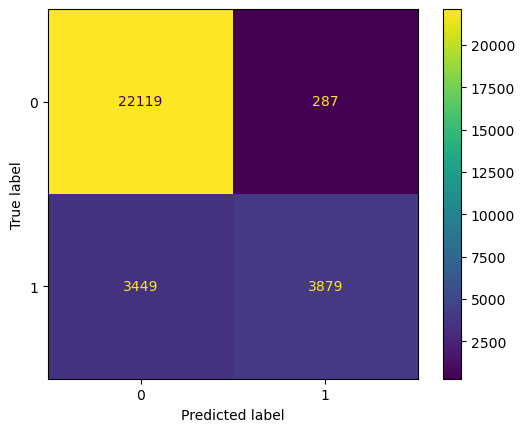

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[22119   287]
 [ 3449  3879]]


The first box in the confusion matrix shows us the number of True Negatives (the loan actually is a default and the model correctly predicted it to be a default). This aligns with the 0.99 recall we observed in the classification report, as we can see that the model is able to correctly non-defaults most of the time. The second box in the confusion matrix represents the number of False Positives, or in other words, the number of non-defaulted loans that were incorrectly classified as defaulted. This is far less compared to the number of True Negatives, reinforcing our analysis that the model does not tend to misclassify non-defaulted loans as defaulted loans.

We can see that the model incorrectly classified 3,449 defaulted loans as non-defaults, which are False Negatives. This is greater than the number of False Positives the model achieved, reinforcing our conclusion about a bias toward the non-defaulted class. Finally, the model captured 3,879 True Positives, or in other words, correctly identified 3,880 defailted loans. 

In [61]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.8743525929911885


In [62]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8657599049420246

While accuracy measures how often the model correctly predicted the default loan class based on the default 0.5 threshold, the ROC-AUC score evaluates how often the model gives the default class a higher probability of default, regardless of a specific threshold.  

The Logistic Regression model achieved strong overall performance, with an accuracy and ROC-AUC of approximately 87%, indicating that it effectively distinguished between defaulted and non-defaulted loans. However, the recall for the default class was approximately 53%, meaning that nearly half of the loans that are actually defaults were classified as non-defaults. This may suggest that while the model successfully ranked default risk, the default classification threshold of 0.5 resulted in many true defaults being missed. Furthermore, because the dataset contains a larger proportion of non-default loans, the high overall accuracy is influenced by the model's strong performance on the majority class.

I will now implement a RandomForest Model. While the Logistic Regression model serves as a linear baseline model that assigns coefficients to determine how much each predictor linearly contributes to the target, the RandomForest model identifies non-linear interactions between features as well.

**RandomForest Model**

In [63]:
#Random Forest model uses the unscaled data X_train_unscaled, X_test_unscaled
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_unscaled, y_train)
y_pred_rf = rf.predict(X_test_unscaled)
y_prob_rf = rf.predict_proba(X_test_unscaled)[:,1] #all rows, but specifically the defaulted loans class (status = 1)

In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734



The above result shows potential target/data leakage, as accuracy scores and precision/recall/and f1-scores of 1.00 are over-inflated. This suggests our model is biased and may not be generalizable.

In [83]:
print(X_train_unscaled.columns)

Index(['loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'property_value', 'income', 'credit_score',
       'ltv', 'dtir1', 'loan_limit_ncf', 'gender_Joint', 'gender_Male',
       'gender_Sex Not Available', 'approv_in_adv_pre', 'loan_type_type2',
       'loan_type_type3', 'loan_purpose_p2', 'loan_purpose_p3',
       'loan_purpose_p4', 'credit_worthiness_l2', 'open_credit_opc',
       'business_or_commercial_nob/c', 'neg_ammortization_not_neg',
       'interest_only_not_int', 'lump_sum_payment_not_lpsm',
       'construction_type_sb', 'occupancy_type_pr', 'occupancy_type_sr',
       'secured_by_land', 'total_units_2U', 'total_units_3U', 'total_units_4U',
       'credit_type_CRIF', 'credit_type_EQUI', 'credit_type_EXP',
       'co-applicant_credit_type_EXP', 'age_35-44', 'age_45-54', 'age_55-64',
       'age_65-74', 'age_<25', 'age_>74', 'submission_of_application_to_inst',
       'region_North-East', 'region_central', 'region_south',
       's

In [84]:
print("status" in X_train_unscaled.columns)

False


In [85]:
print(X_train_unscaled.shape)

(118936, 48)


In [86]:
print(X_test_unscaled.shape)

(29734, 48)


In [87]:
print(len(y_train))

118936


In [88]:
print(len(y_test))

29734


In [89]:
import numpy as np
print(np.array_equal(y_pred, y_test))

False


In [90]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train_unscaled.columns
).sort_values(ascending=False)

rf_importance.head(15)

interest_rate_spread                 0.299731
upfront_charges                      0.256487
rate_of_interest                     0.176341
credit_type_EQUI                     0.106956
property_value                       0.039992
ltv                                  0.025654
dtir1                                0.021200
income                               0.010503
lump_sum_payment_not_lpsm            0.009153
neg_ammortization_not_neg            0.006542
co-applicant_credit_type_EXP         0.005894
submission_of_application_to_inst    0.005456
loan_amount                          0.005415
loan_type_type2                      0.003697
business_or_commercial_nob/c         0.003241
dtype: float64

The above result suggests that the model is using the interest_rate_spread, upfront_charges, and rate_of_interest columns to make its decisions. If we recall from our missing value analysis, these columns had the highest proportion of missing values and close to 100% of defaulted loans had missing values in these columns. While the logistic regression model assigns coefficients to capture linear relationships, the tree-based model identifies values which lead to optimal splits to classify the target. Therefore, after confirming that the testing and training are different and data leakage is likely not the cause for the over-inflated classification report metrics, we can conclude that the model is relying on these features which are implicitly encoding the target through the pattern of missingness (though the missigness was corrected, it is still identifiable by the median or mode)

To test this hypothesis, I will drop these columns and assess the performance of this reduced model. This will ensure that our model is identifying more generalizable patterns, rather than relying on systemic missingness. However, because features like rate_of_interest and upfront_charges do carry domain weight and as seen in our exploratory data analysis, do vary by default status, we can expect the predictive performance of the model to be slightly reduced as well. 

In [80]:
suspicious_cols = ["rate_of_interest", "upfront_charges", "interest_rate_spread"]

X_train_rf_reduced = X_train_unscaled.drop(columns=suspicious_cols)
X_test_rf_reduced = X_test_unscaled.drop(columns=suspicious_cols)

rf_reduced = RandomForestClassifier(random_state=42)
rf_reduced.fit(X_train_rf_reduced, y_train)

y_pred_rf_reduced = rf_reduced.predict(X_test_rf_reduced)
y_prob_rf_reduced = rf_reduced.predict_proba(X_test_rf_reduced)[:,1]

print(classification_report(y_test, y_pred_rf_reduced))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.94      0.60      0.73      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.79      0.83     29734
weighted avg       0.90      0.89      0.88     29734



The performance of the reduced random forest model appears to be more reasonable. For the non-defaulted class, the model achieved a precision of 0.88, meaning that of the total number of loans classified as non-defaults, 88% were correctly classified. The model achieved a 0.99 recall for the non-defaulted class, meaning that it is classifying almost all non-defaulted loans. These results are largely similar to those achieved by the logistic regression baseline. 

For the defaulted class, the model achieved a precision of 0.94. This means that of those loans that the model classified as defaults, 94% are actually defaults. The model achieved a recall of 0.60, so 60% of actual defaulted loans were classified correctly. While the lower recall score for the defaulted class suggests the need for improvement to prevent False Negatives (defaults being missed), the random forest model shows an improvement in its classification of defaulted loans compared to the logistic regression model. 

Before I analyze the confusion matrix, I want to analyze the feature importance to examine what features the reduced model is relying on (compared to the unreduced model that largely relied on features with systemic missingness).

In [95]:
rf_importance = pd.Series(
    rf_reduced.feature_importances_,
    index=X_train_rf_reduced.columns
).sort_values(ascending=False)

rf_importance

credit_type_EQUI                     0.167748
ltv                                  0.127432
dtir1                                0.114122
property_value                       0.113440
income                               0.085442
credit_score                         0.066276
loan_amount                          0.060196
co-applicant_credit_type_EXP         0.022011
lump_sum_payment_not_lpsm            0.019062
credit_type_EXP                      0.016704
neg_ammortization_not_neg            0.016601
credit_type_CRIF                     0.015786
term                                 0.014082
loan_purpose_p4                      0.010163
loan_type_type3                      0.009840
loan_purpose_p3                      0.009713
submission_of_application_to_inst    0.009700
approv_in_adv_pre                    0.009111
gender_Male                          0.008845
age_45-54                            0.008702
age_55-64                            0.008414
region_south                      

We can see that the feature importance seems more balanced, suggesting that the model is not mostly dominated by a few features. While this model does have lower classification report metrics compared to the unreduced RandomForest model, the model seems to be more balanced and less dependent on unique attributes of this particular dataset (the systemic missingness), and therefore more generalizable.

Analyzing the Confusion Matrix

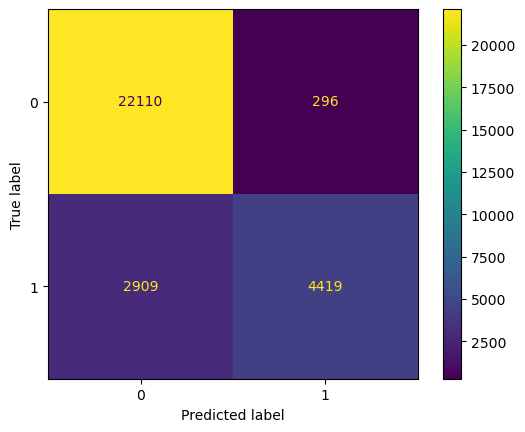

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay

print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_reduced))

Analyzing the confusion matrix, there are 22110 True Negatives (correctly predicted non-defaults), 296 False Positives (non-defaults incorrectly predicted to be defaults), 2909 False Negatives (defaults incorrectly predicted to be non-defaults), and 4419 True Positives, or correctly predicted defaulted loans. 

Overall, looking at the confusion matrix for the RandomForest model, we can see that the total number of correctly classified defaulted loans increased by 540 loans. While the number of false positives increased by 9 loans, these results suggest that the RandomForest model is more likely to classify the default class compared to the Logistic Regression Model

Analyzing Accuracy and ROC-AUC score

In [96]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred_rf_reduced))

0.8922109369745073


In [97]:
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, y_prob_rf_reduced))

0.8875514485651262


From the above results, the randomforest model has better accuracy and a higher ROC-AUC score. The accuracy score of approximately 89.22% indicates that the RandomForest model correctly classified 89% of loans in the test set. The ROC-AUC indicates that approximately 88.76% of the time, the RandomForest model assigns true defaulted loans a higher probability of default compared to true non-default loans. 

Overall, the results of the classification report, confusion matrix, accuracy score and ROC-AUC score suggest that the RandomForest model is more sensitive to defaulted loans and is therefore likelier to classify true defaulted loans correctly compared to the baseline Logistic Regression Model. This improvement is important because in a business context, correctly identifying defaults can help minimize lender loss. 

Note, that when making comparisons between the baseline Logistic Regression Model and our RandomForest model, we also have to taken account that the models are not trained using the same feature set. While the logistic regression model was trained using all features (including those with systemic missingness), the RandomForest model trained using the same feature set resulted in artificially inflated values that indicate the target being encoded within the feature set itself, which is why we are using the Random Forest model based on the reduced feature set. 

However, the above results show that even using the reduced feature set, the Random Forest model achieved improvement over the full feature set logistic regression model, suggesting that it may be picking up on nonlinear relationships the logistic regression model may be missing. To more definitively compare logistic regression vs Random Forest, I will fit the logistic regression model on the reduced feature set as well, before moving onto XGBoost.

**Fitting Reduced Feature set Logistic Regression**

In [107]:
X_train_scaled_reduced = X_train_scaled.drop(columns=["rate_of_interest", "upfront_charges", "interest_rate_spread"])
X_test_scaled_reduced = X_test_scaled.drop(columns=["rate_of_interest", "upfront_charges", "interest_rate_spread"])

from sklearn.linear_model import LogisticRegression
logistic_reduced = LogisticRegression(
    penalty="l2",
    random_state=42,
    max_iter=1000
)

logistic_reduced.fit(X_train_scaled_reduced, y_train)

y_pred_logistic_reduced = logistic_reduced.predict(X_test_scaled_reduced)
y_proba_logistic_reduced = logistic_reduced.predict_proba(X_test_scaled_reduced)[:, 1]

In [108]:
print(classification_report(y_test, y_pred_logistic_reduced))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22406
           1       0.95      0.50      0.65      7328

    accuracy                           0.87     29734
   macro avg       0.90      0.74      0.79     29734
weighted avg       0.88      0.87      0.85     29734



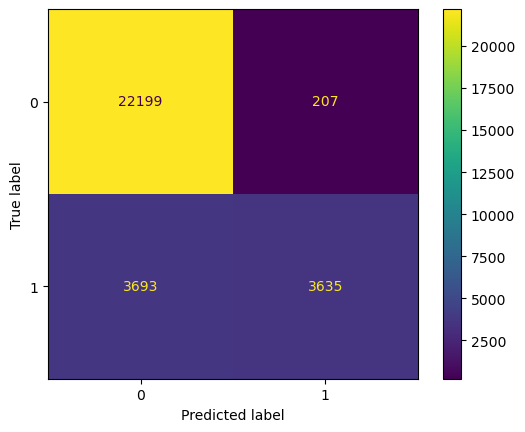

In [109]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logistic_reduced))

In [110]:
print(accuracy_score(y_test, y_pred_logistic_reduced))

0.8688370215914442


In [112]:
print(roc_auc_score(y_test, y_pred_logistic_reduced))

0.7434019898073934


Looking at the above metrics, we can see that in terms of precision/recall/f1-score, the reduced logistic regression model's performance is slightly lower than both the full feature-logistic regression model and the reduced feature random forest model. Specifically, while precision and recall for the negative majority class stayed approximately the same, recall for the minority positive class (loan defaults) is lower by 3% compared to the original logistic regression model and by 10% compared to the reduced randomforest model. 

Examining the confusion matrix, the reduced Logistic Regression model correctly identified fewer defaulted loans (true positives) while misclassifying more defaulted loans as non-defaults (false negatives). At the same time, it incorrectly classified fewer non-defaulted loans as defaults (false positives), resulting in a slight increase in correctly classified non-defaulted loans (true negatives).

The reduced logistic regression model's accuracy is lower than that achieved by the full feature logistic model as well as the reduced random forest model, and the ROC-AUC score is also more than 10% lower than the previous models'. 

These findings suggest that the reduced logistic regression model is less likely to identify defaults compared to the baseline logistic model and the reduced random forest model. 
Because both models were trained using the same reduced feature set, this allows us to isolate the effect of the actual model algorithm rather than differences in the available predictors when comparing the results of both models. 

Overall, the Random Forest model is better able to capture nonlinear relationships and feature interactions within the reduced feature set. Despite having access to the same predictors as the reduced Logistic Regression model, the Random Forest achieved higher recall for loan defaults, higher accuracy, and a higher ROC-AUC score, indicating a stronger ability to distinguish between defaulted and non-defaulted loans.

**Implementing XGBoost Model**

I will now fit an XGBoost Model to the dataset and compare this against the models developed until now: baseline logistic regression, reduced random forest, and reduced logistic regression.

Like the Random Forest model, the XGBoost Model is a tree-based/ensemble model that captures non-linear feature interactions. However, like RandomForest, XGBoost can take advantage of quirks or patterns in the dataset when determining optimal splits. Therefore, to ensure a generalizable model, as well as maintain comparability across the developed models, I will fit the model using the reduced feature set. 

In [113]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.8 MB/s eta 0:00:00a 0:00:010m
Note: you may need to restart the kernel to use updated packages.


In [114]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [ ]:
#fiting the xgboost model on the unscaled training data
#before we fit the model, we have to drop interest_rate_spread, rate_of_interest, and upfront_charges once again for model consistency

suspicious_cols = ["rate_of_interest", "upfront_charges", "interest_rate_spread"]
X_train_xg_reduced = X_train_unscaled.drop(columns=suspicious_cols) 
X_test_xg_reduced = X_test_unscaled.drop(columns=suspicious_cols)

#Note, the above dataframes (with reduced columns) are equivalent to those we used for the randomforest model

For XGBoost, we must clean the column names to ensure that there are no [, ], <, >. Checking if any columns in our train and test sets have such characters:

In [125]:
[col for col in X_train_xg_reduced.columns if any(c in str(col) for c in ["[", "]", "<"])]

['age_<25']

In [124]:
[col for col in X_test_xg_reduced.columns if any(c in str(col) for c in ["[", "]", "<"])]

['age_<25']

Because both the train and test sets contain columns with characters that XGBoost will not accept, we must replace these characters 

In [126]:
X_train_xg_reduced.columns = (
    X_train_xg_reduced.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
)

In [127]:
X_test_xg_reduced.columns = (
    X_test_xg_reduced.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
)

Now that we have cleaned up the columns, we can fit the XGBoost model on our reduced feature dataframes

In [128]:
xgb_model.fit(X_train_xg_reduced, y_train)

#predicting
y_pred = xgb_model.predict(X_test_xg_reduced)
y_prob = xgb_model.predict_proba(X_test_xg_reduced)[:, 1]

In [129]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.94     22406
           1       0.92      0.64      0.76      7328

    accuracy                           0.90     29734
   macro avg       0.91      0.81      0.85     29734
weighted avg       0.90      0.90      0.89     29734



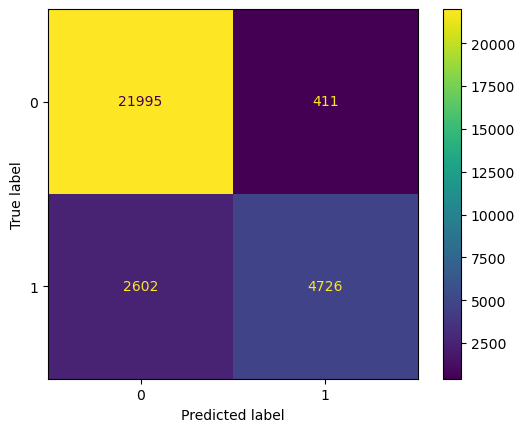

In [130]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))

In [137]:
y_test.value_counts()

status
0    22406
1     7328
Name: count, dtype: int64

In [131]:
print(accuracy_score(y_test, y_pred))

0.8986681912961593


In [ ]:
print(roc_auc_score(y_test, y_prob))

0.8944202954936041


The XGBoost model achieved higher recall for the positive (defaulted loans) class but lower precision. For the non-defaulted loans class, precision increased from 0.88 for the randomforest model to 0.89. Recall slightly decreased for the non-defaulted loans class from 0.99 to 0.98. 

The confusion matrix shows that the number of True Positives (4726) increased compared to the random forest model (4419), indicating that the model is correctly classifying more defaulted loans. The number of False Negatives (2602) also decreased, so the XGBoost is classifying defaulted loans as non-defaults less often. The number of False Positives (411) increased and the number of True Negatives decreased. This results indicate that the model is more sensitive to defaulted loans than the previous models and suggests that the model is likelier to correctly capture defaulted loans. 

The accuracy and ROC-AUC score improved slightly from the random forest model. The improvement in ROC-AUC reinforces our prior findings about the model's improved ability to identify defaulted loans as it indicates that the model tends to assign a greater probability of default for defaulted loans over non-defaulted loans 89% of the time. 

Overall, the XGBoost model has achieved the most optimal results thus far, as it correctly identifies more defaulted loans, achieving a considerable increase in recall compared to the previous models. Of the 7,328 total defaults in the test set, the model predicted about 64.49% correctly. 

While the model has achieved considerable accuracy and improved recall, considering that the dataset is imbalanced and the default class is the minority class, I want to examine how applying class weighting affects the model's performance, particularly with respect to recall and the classification of defaulted loans. I will apply class weights to both the reduced random forest model and the reduced XGBoost model. 

**Applying Class Weights to the Random Forest Model**

In [138]:
from sklearn.ensemble import RandomForestClassifier

rf_weighted = RandomForestClassifier(random_state=42, class_weight="balanced")

rf_weighted.fit(X_train_rf_reduced, y_train)
y_pred = rf_weighted.predict(X_test_rf_reduced)
y_proba = rf_weighted.predict_proba(X_test_rf_reduced)[:, 1]

In [139]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.95      0.58      0.72      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.79      0.83     29734
weighted avg       0.90      0.89      0.88     29734



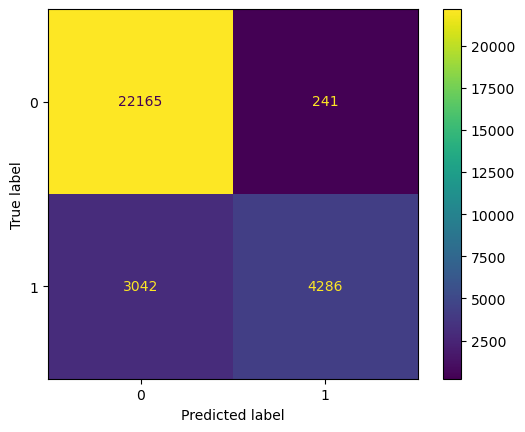

In [140]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))

In [141]:
print(accuracy_score(y_test, y_pred))

0.8895876774063362


In [149]:
print(roc_auc_score(y_test, y_prob))

0.8962724048591945


**Applying class weights to XGBoost Model**

In [ ]:
#must calculate class weights ourself
neg_class = (y_train == 0).sum() #summing all the non-defaults
pos_class = (y_train == 1).sum() #summing all the defaults

#we can expect the negative class (non-defaults) to be 3x the positive class (defaults), based on what we know about our dataset breakdown
scale_pos_weight = neg_class / pos_class

In [144]:
#building the modified XGBoost model with class weights applied

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state = 42, 
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train_xg_reduced, y_train) #note we corrected the columns already to ensure they are compatible with XGBoost

y_pred = xgb_model.predict(X_test_xg_reduced)
y_prob = xgb_model.predict_proba(X_test_xg_reduced)[:,1]

In [145]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     22406
           1       0.98      0.59      0.73      7328

    accuracy                           0.89     29734
   macro avg       0.93      0.79      0.83     29734
weighted avg       0.90      0.89      0.88     29734



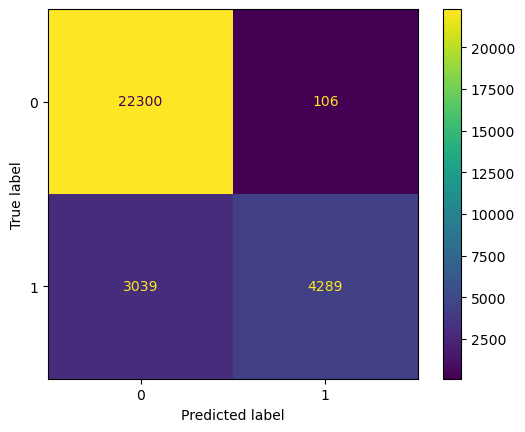

In [146]:
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred))

In [147]:
print(accuracy_score(y_test, y_pred))

0.8942288289500235


In [148]:
print(roc_auc_score(y_test, y_prob))

0.8962724048591945
